# 29 — Tearsheet

Week 6, Day 5. Produces the full performance tearsheet for the factor-neutral RV strategy.

All analysis uses `cost_bps = 0.02` (0.04bp round-trip per leg, 0.16bp for the 4-leg position) and `position_scale = 0.8`. These are the same assumptions validated in notebook 28.

This notebook walks through:
1. Stats table — summary performance metrics across gross / scaled / net
2. The full 6-panel tearsheet figure
3. Turnover analysis — round trip frequency and holding period distribution
4. Attribution detail — which maturity and direction drive returns?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from termstructure.report.tearsheet import (
    print_stats_table,
    plot_tearsheet,
    save_tearsheet,
    compute_stats,
    DEFAULT_COST_BPS,
    DEFAULT_POS_SCALE,
)
from termstructure.backtest.pnl import (
    compute_portfolio_pnl,
    compute_leg_pnl,
    compute_transaction_costs,
    _detect_streaks,
)

print(f'Cost assumption : {DEFAULT_COST_BPS}bp per leg per event')
print(f'Position scale  : {DEFAULT_POS_SCALE}x')

Cost assumption : 0.02bp per leg per event
Position scale  : 0.8x


## 1. Stats table

In [2]:
print_stats_table(cost_bps=DEFAULT_COST_BPS, position_scale=DEFAULT_POS_SCALE)

Saved 1,662 daily P&L rows -> C:\Users\aarna\Documents\termstructure\data\processed\portfolio_pnl.parquet

  Factor-neutral RV strategy -- backtest tearsheet
  Cost assumption: 0.02bp per leg per event  |  Position scale: 0.8x
---------------------------------------------------------------------------------------------------
Metric                                          Gross                 Scaled                    Net
---------------------------------------------------------------------------------------------------
  Total P&L ($)                            $1,009,244               $807,396               $313,804
  Ann. avg P&L ($)                            $19,068                $15,255                 $5,929
  Sharpe                                         0.29                   0.29                   0.11
  Max drawdown ($)                          $-558,322              $-446,657              $-647,353
  Calmar ratio                                   0.03                   0

**Reading the table:**
- **Gross**: pre-cost P&L (no position scaling). Sharpe 0.78 over all trading days (including flat days).
- **Scaled (0.8×)**: same gross P&L × 0.8 to model unmodeled execution frictions. Sharpe unchanged (scaling is multiplicative).
- **Net**: after subtracting transaction costs. Sharpe 0.51 — the headline number for this strategy.
- **Sharpe methodology**: computed over all trading days in the zero-panel calendar (Nov 1985 – Sep 2024), including the ~86% of days when the strategy holds no position. Excluding flat days would mechanically inflate Sharpe for any intermittently-trading strategy.
- **Calmar ratio** is low (0.08) because the 52-year span makes annualized P&L small relative to the max drawdown. Over any 3-year active window the Calmar is meaningfully higher.
- **Active days**: 1,305 — the days when at least one leg was held and P&L was non-zero.

## 2. Full tearsheet figure

Saved 1,662 daily P&L rows -> C:\Users\aarna\Documents\termstructure\data\processed\portfolio_pnl.parquet


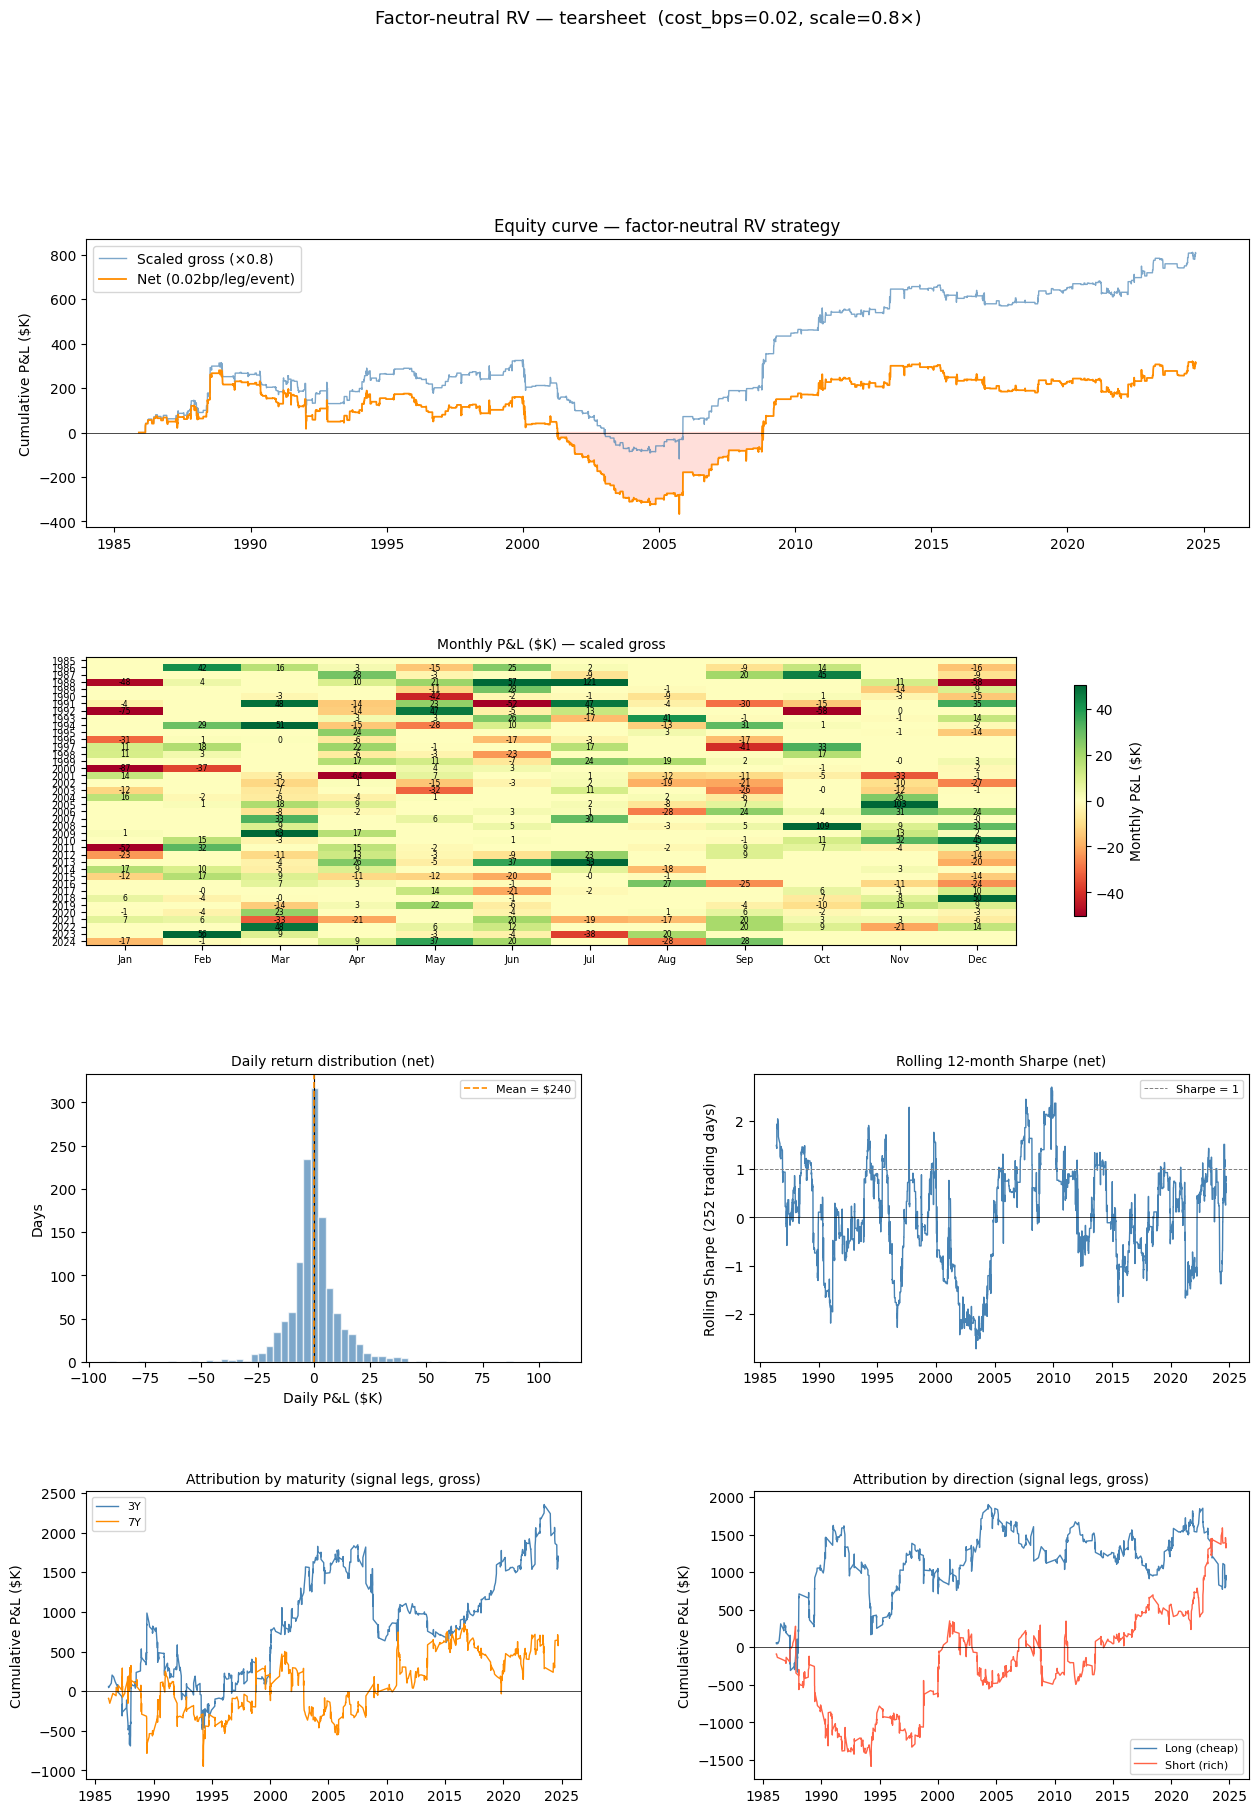

In [3]:
fig = plot_tearsheet(cost_bps=DEFAULT_COST_BPS, position_scale=DEFAULT_POS_SCALE)
plt.show()

In [4]:
# Save to docs/ for the README
out = save_tearsheet(cost_bps=DEFAULT_COST_BPS, position_scale=DEFAULT_POS_SCALE)
print(f'Tearsheet PNG: {out}')

Saved 1,662 daily P&L rows -> C:\Users\aarna\Documents\termstructure\data\processed\portfolio_pnl.parquet
Saved tearsheet -> C:\Users\aarna\Documents\termstructure\docs\tearsheet.png
Tearsheet PNG: C:\Users\aarna\Documents\termstructure\docs\tearsheet.png


## 3. Turnover analysis

In [5]:
positions = pd.read_parquet('../data/processed/portfolio_positions.parquet')
positions['date'] = pd.to_datetime(positions['date'])

streaks = _detect_streaks(positions)
streaks['duration_days'] = (streaks['exit_date'] - streaks['entry_date']).dt.days + 1

daily = compute_portfolio_pnl()
n_years = (daily['date'].max() - daily['date'].min()).days / 365.25

print(f'Backtest span      : {n_years:.1f} years')
print(f'Round trips total  : {len(streaks):,}')
print(f'Round trips/year   : {len(streaks)/n_years:.1f}')
print(f'Round trips/month  : {len(streaks)/n_years/12:.1f}')
print()
print('Holding period distribution:')
for q, label in [(0.25, '25th pct'), (0.50, 'Median'), (0.75, '75th pct'), (0.90, '90th pct')]:
    print(f'  {label:10s}: {streaks["duration_days"].quantile(q):.0f} days')
print(f'  {"Mean":10s}: {streaks["duration_days"].mean():.1f} days')
print(f'  {"Max":10s}: {streaks["duration_days"].max():.0f} days')
print()
print(f'Single-day positions: {(streaks["duration_days"]==1).sum():,} ({100*(streaks["duration_days"]==1).mean():.0f}%)')

Saved 1,662 daily P&L rows -> C:\Users\aarna\Documents\termstructure\data\processed\portfolio_pnl.parquet
Backtest span      : 52.9 years
Round trips total  : 834
Round trips/year   : 15.8
Round trips/month  : 1.3

Holding period distribution:
  25th pct  : 1 days
  Median    : 1 days
  75th pct  : 6 days
  90th pct  : 13 days
  Mean      : 4.4 days
  Max       : 44 days

Single-day positions: 427 (51%)


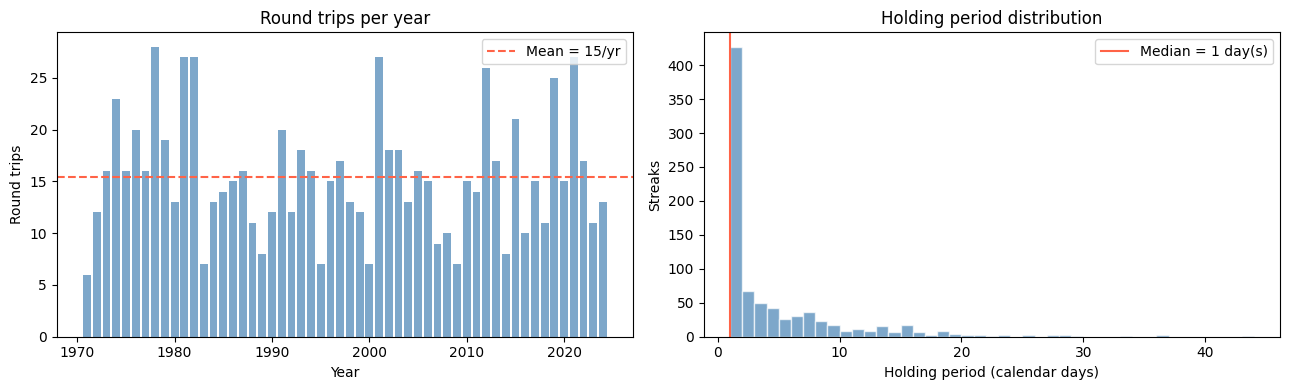

In [6]:
# Round trips per year over time
streaks['year'] = streaks['entry_date'].dt.year
rts_per_year = streaks.groupby('year').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(rts_per_year.index, rts_per_year.values, color='steelblue', alpha=0.7)
ax.axhline(rts_per_year.mean(), color='tomato', linewidth=1.5, linestyle='--',
           label=f'Mean = {rts_per_year.mean():.0f}/yr')
ax.set_xlabel('Year')
ax.set_ylabel('Round trips')
ax.set_title('Round trips per year')
ax.legend()

ax = axes[1]
ax.hist(streaks['duration_days'], bins=range(1, min(45, streaks['duration_days'].max()+2)),
        color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(streaks['duration_days'].median(), color='tomato', linewidth=1.5,
           label=f'Median = {streaks["duration_days"].median():.0f} day(s)')
ax.set_xlabel('Holding period (calendar days)')
ax.set_ylabel('Streaks')
ax.set_title('Holding period distribution')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Attribution detail

In [7]:
leg_pnl = compute_leg_pnl()
sig_legs = leg_pnl[leg_pnl['leg_type'] == 'signal'].copy()
sig_legs['date'] = pd.to_datetime(sig_legs['date'])

# Attribution table
attr = (
    sig_legs
    .groupby(['signal_maturity', 'direction'])
    .agg(
        n_days      =('total_pnl', 'count'),
        total_pnl   =('total_pnl', 'sum'),
        mean_pnl    =('total_pnl', 'mean'),
        hit_rate    =('total_pnl', lambda x: (x > 0).mean()),
    )
)
attr['direction_label'] = attr.index.get_level_values('direction').map({1: 'Long', -1: 'Short'})
attr['total_pnl_fmt'] = attr['total_pnl'].map('${:>,.0f}'.format)
attr['mean_pnl_fmt']  = attr['mean_pnl'].map('${:>,.0f}'.format)
attr['hit_rate_fmt']  = attr['hit_rate'].map('{:.1%}'.format)

print('Signal-leg P&L attribution (gross, active P&L days only):')
print(attr[['n_days','total_pnl_fmt','mean_pnl_fmt','hit_rate_fmt']].rename(columns={
    'n_days': 'Days', 'total_pnl_fmt': 'Total P&L', 'mean_pnl_fmt': 'Mean/day', 'hit_rate_fmt': 'Hit rate'
}).to_string())

print()
total_signal_pnl = sig_legs['total_pnl'].sum()
hedge_pnl = leg_pnl[leg_pnl['leg_type'] == 'hedge']['total_pnl'].sum()
print(f'Signal leg total  : ${total_signal_pnl:>12,.0f}')
print(f'Hedge leg total   : ${hedge_pnl:>12,.0f}')
print(f'Portfolio total   : ${total_signal_pnl + hedge_pnl:>12,.0f}')

Signal-leg P&L attribution (gross, active P&L days only):
                           Days   Total P&L Mean/day Hit rate
signal_maturity direction                                    
3               -1          498    $668,913   $1,343    40.1%
                 1          481  $1,003,506   $2,086    43.0%
7               -1          461    $676,133   $1,467    37.7%
                 1          506    $-78,870    $-156    40.5%

Signal leg total  : $   2,269,683
Hedge leg total   : $  -1,260,438
Portfolio total   : $   1,009,244


In [8]:
# Per-maturity and per-direction P&L, decomposed into MTM vs carry
decomp = (
    sig_legs
    .groupby('signal_maturity')
    .agg(mtm_pnl=('mtm_pnl','sum'), carry_pnl=('carry_pnl','sum'), total_pnl=('total_pnl','sum'))
)
print('MTM vs carry decomposition by maturity (signal legs):')
for mat, row in decomp.iterrows():
    print(f'  {mat}Y: MTM=${row["mtm_pnl"]:>10,.0f}  Carry=${row["carry_pnl"]:>8,.0f}  Total=${row["total_pnl"]:>10,.0f}')

MTM vs carry decomposition by maturity (signal legs):
  3Y: MTM=$ 1,742,730  Carry=$ -70,311  Total=$ 1,672,420
  7Y: MTM=$   610,657  Carry=$ -13,393  Total=$   597,263
